In [1]:
#masukan data set yang kita bbutuh kan

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
data_model = pd.read_csv('data_model_classificaton_banery.csv')
data_model.head(10) #MELIAHT 10 DATA TERATAS

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_binary
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,1
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,0
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,1
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,1
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,0
5,100006,19,Male,BSc,3rd,8.2,4.8,4.1,High,8,4,9,8,2,1.9,Poor,51.7,6.82,Average,0
6,100007,23,Other,BSc,2nd,3.0,8.0,7.8,Low,5,9,9,2,6,0.5,Average,77.1,5.36,Average,0
7,100008,24,Male,BTech,2nd,4.6,6.3,7.6,Medium,5,10,3,10,6,0.6,Poor,59.3,5.91,Average,0
8,100009,21,Male,MBA,3rd,8.1,5.4,1.3,Low,1,1,7,2,1,1.7,Average,70.6,7.23,Average,0
9,100010,20,Male,BCA,3rd,9.7,7.0,11.5,Medium,4,2,4,3,7,1.3,Poor,65.0,6.26,Poor,1


In [2]:
#data clanning
data_model.info() #melihat informasi tentang data set kita
data_model.describe() #melihat statistik data seprti mean, median, juumlah data, data unique, dll

#non-null dalam data_model adalah 1000, artinya tidak ada data yang kosong atau null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

,student_id,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa,burnout_binary
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,175000.500000,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389,0.664900
std,43301.414527,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180,0.472027
min,100001.000000,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000,0.000000
25%,137500.750000,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000,0.000000
50%,175000.500000,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000,1.000000
75%,212500.250000,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000,1.000000
max,250000.000000,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000,1.000000


In [3]:
data_model.isnull().sum() #melihat missing value pada data set kita


student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_binary             0
dtype: int64

In [4]:
data_model.duplicated().sum() #melihat data duplikat

0

In [5]:
data_model.isna().sum() #melihat data yang kosong

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_binary             0
dtype: int64

In [6]:
data_finalmodel = data_model.drop(columns=['student_id'], axis=1) #menghapus kolom student_id karena tidak berpengaruh pada model kita
data_finalmodel.head(10) #melihat 10 data teratas setelah menghapus kolom student_id

,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_binary
0,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,1
1,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,0
2,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,1
3,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,1
4,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,0
5,19,Male,BSc,3rd,8.2,4.8,4.1,High,8,4,9,8,2,1.9,Poor,51.7,6.82,Average,0
6,23,Other,BSc,2nd,3.0,8.0,7.8,Low,5,9,9,2,6,0.5,Average,77.1,5.36,Average,0
7,24,Male,BTech,2nd,4.6,6.3,7.6,Medium,5,10,3,10,6,0.6,Poor,59.3,5.91,Average,0
8,21,Male,MBA,3rd,8.1,5.4,1.3,Low,1,1,7,2,1,1.7,Average,70.6,7.23,Average,0
9,20,Male,BCA,3rd,9.7,7.0,11.5,Medium,4,2,4,3,7,1.3,Poor,65.0,6.26,Poor,1


In [7]:
data_finalmodel.info() #melihat informasi tentang data set kita setelah menghapus kolom student_id

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   gender                   150000 non-null  object 
 2   course                   150000 non-null  object 
 3   year                     150000 non-null  object 
 4   daily_study_hours        150000 non-null  float64
 5   daily_sleep_hours        150000 non-null  float64
 6   screen_time_hours        150000 non-null  float64
 7   stress_level             150000 non-null  object 
 8   anxiety_score            150000 non-null  int64  
 9   depression_score         150000 non-null  int64  
 10  academic_pressure_score  150000 non-null  int64  
 11  financial_stress_score   150000 non-null  int64  
 12  social_support_score     150000 non-null  int64  
 13  physical_activity_hours  150000 non-null  float64
 14  slee

In [8]:
data_finalmodel.tail(10) #melihat 10 data terakhir pada data set kita

,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_binary
149990,18,Female,BTech,1st,6.3,7.7,1.6,High,9,6,4,5,2,1.5,Average,89.8,5.48,Good,1
149991,17,Female,MCA,4th,7.0,6.7,10.2,Medium,10,4,1,4,8,0.3,Good,86.1,4.67,Average,1
149992,21,Male,BTech,4th,5.4,8.5,9.7,Low,7,5,7,1,7,1.6,Good,52.3,6.35,Good,1
149993,17,Female,BCA,4th,8.7,7.3,3.5,Medium,9,1,7,9,7,1.8,Poor,99.8,4.31,Good,1
149994,20,Male,MCA,4th,6.3,5.4,9.6,Medium,9,5,10,8,1,0.6,Good,77.2,9.31,Good,0
149995,24,Female,BSc,3rd,1.6,8.2,11.3,Medium,9,9,5,3,10,2.0,Good,54.2,7.82,Good,0
149996,25,Male,BCA,3rd,9.9,4.8,1.6,High,10,3,10,10,2,0.1,Poor,53.6,7.19,Average,1
149997,22,Male,BTech,1st,1.4,4.4,4.6,High,10,8,6,4,7,1.6,Good,90.7,9.78,Average,1
149998,19,Male,BSc,3rd,1.5,4.3,1.1,Medium,8,6,5,7,4,1.1,Average,83.9,9.88,Average,1
149999,20,Male,MCA,3rd,3.7,6.6,2.6,Medium,5,1,5,7,6,1.8,Good,89.8,7.00,Poor,1


In [9]:
data_finalmodel.describe() #melihat statistika dalam data set kita

,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa,burnout_binary
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389,0.664900
std,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180,0.472027
min,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000,0.000000
25%,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000,0.000000
50%,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000,1.000000
75%,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000,1.000000
max,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000,1.000000


In [10]:
data_finalmodel.isna().sum() #melihat data yang kosong pada data set kita


age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_binary             0
dtype: int64

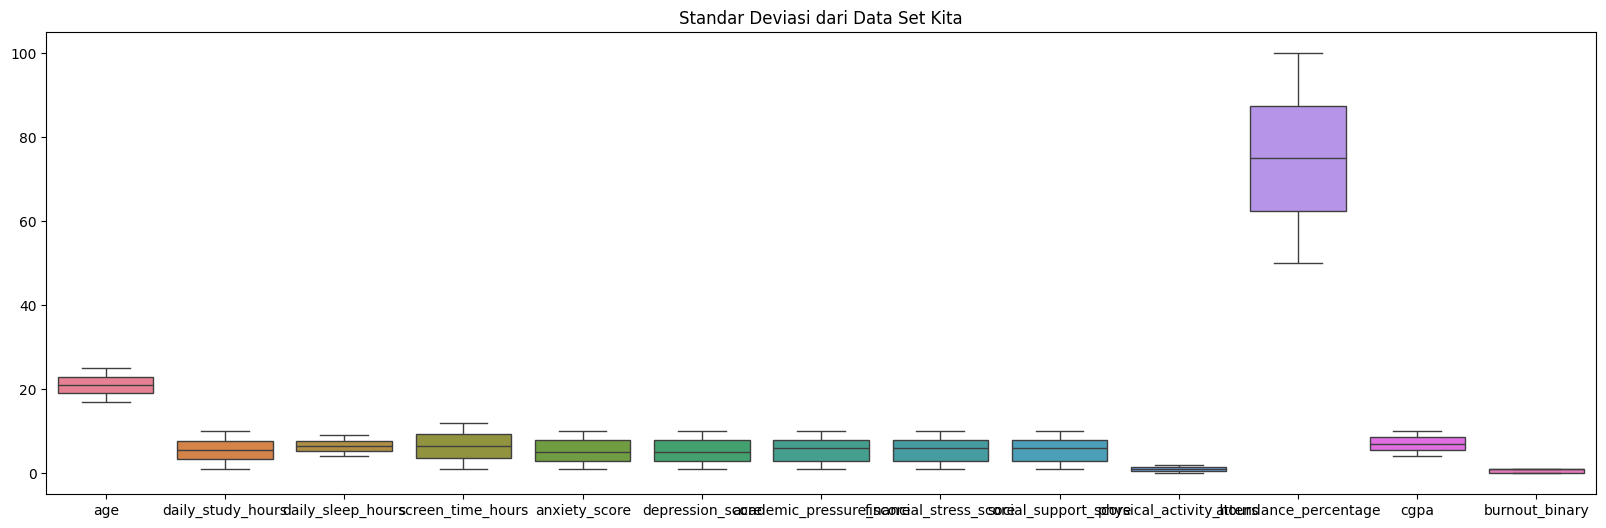

In [11]:
plt.figure(figsize=(20,6))
plt.title('Standar Deviasi dari Data Set Kita')
sns.boxplot(data=data_finalmodel)
plt.show() #melihat boxplot dari data set kita

In [12]:

data_object = data_finalmodel.select_dtypes(include='object') #melihat data yang bertipe object pada data set kita

In [13]:
for i in data_object.columns:
   print(f'====== distribusi frekuensi dari vareabel {i} ======')
   print(data_object[i].value_counts())
   
   

====== distribusi frekuensi dari vareabel gender ======
gender
Other     50048
Female    49988
Male      49964
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel course ======
course
MBA      25231
BBA      25103
BCA      24973
MCA      24950
BSc      24894
BTech    24849
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel year ======
year
1st    37680
4th    37622
3rd    37422
2nd    37276
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel stress_level ======
stress_level
High      50295
Medium    50090
Low       49615
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel sleep_quality ======
sleep_quality
Good       50143
Average    49976
Poor       49881
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel internet_quality ======
internet_quality
Average    50138
Poor       49989
Good       49873
Name: count, dtype: int64


In [15]:
data_numerik = data_finalmodel.select_dtypes(include=['float64', 'int64']) #melihat data yang bertipe numerik pada data set kita
print(data_numerik) #melihat 10 data teratas pada data numerik


        age  daily_study_hours  daily_sleep_hours  screen_time_hours  \
0        23                4.3                6.8                6.1   
1        20                1.4                4.7                3.0   
2        24                3.7                4.8                1.5   
3        21                1.6                6.7                7.0   
4        23                2.0                6.7                5.4   
...     ...                ...                ...                ...   
149995   24                1.6                8.2               11.3   
149996   25                9.9                4.8                1.6   
149997   22                1.4                4.4                4.6   
149998   19                1.5                4.3                1.1   
149999   20                3.7                6.6                2.6   

        anxiety_score  depression_score  academic_pressure_score  \
0                  10                 3                        4   

In [16]:
#ukuran pemusatan data di data numerik
for i in data_numerik.columns:
    print(f'====== UKURAN PEMUSATAN DATA DARI VARIABEL {i} ======')
    print(f'====== mean ========')
    print(data_numerik[i].mean())
    print(f'====== median ========')
    print(data_numerik[i].median()) 
    print(f'====== modus ========')
    print(data_numerik[i].mode()[0])

====== UKURAN PEMUSATAN DATA DARI VARIABEL age ======
====== mean ========
21.00038
====== median ========
21.0
====== modus ========
23
====== UKURAN PEMUSATAN DATA DARI VARIABEL daily_study_hours ======
====== mean ========
5.507868666666667
====== median ========
5.5
====== modus ========
5.5
====== UKURAN PEMUSATAN DATA DARI VARIABEL daily_sleep_hours ======
====== mean ========
6.499361333333334
====== median ========
6.5
====== modus ========
5.0
====== UKURAN PEMUSATAN DATA DARI VARIABEL screen_time_hours ======
====== mean ========
6.502819333333332
====== median ========
6.5
====== modus ========
4.2
====== UKURAN PEMUSATAN DATA DARI VARIABEL anxiety_score ======
====== mean ========
5.493906666666667
====== median ========
5.0
====== modus ========
2
====== UKURAN PEMUSATAN DATA DARI VARIABEL depression_score ======
====== mean ========
5.49736
====== median ========
5.0
====== modus ========
3
====== UKURAN PEMUSATAN DATA DARI VARIABEL academic_pressure_score ======
====== m

In [14]:
#ukuran pemusatan data di data ketegorial
for i in data_object.columns:
   print(f'====== ukuran pemusatan data dari vareabel {i} ======')
   print(data_object[i].mode()[0])

====== ukuran pemusatan data dari vareabel gender ======
Other
====== ukuran pemusatan data dari vareabel course ======
MBA
====== ukuran pemusatan data dari vareabel year ======
1st
====== ukuran pemusatan data dari vareabel stress_level ======
High
====== ukuran pemusatan data dari vareabel sleep_quality ======
Good
====== ukuran pemusatan data dari vareabel internet_quality ======
Average


In [17]:
for i in data_numerik.columns:
    data_numerik[i].unique() #melihat data unik pada data numerik
    print(f"Data unik pada variabel {i}: {data_numerik[i].unique()}")

Data unik pada variabel age: [23 20 24 21 19 22 18 17 25]
Data unik pada variabel daily_study_hours: [ 4.3  1.4  3.7  1.6  2.   8.2  3.   4.6  8.1  9.7  2.2  8.9  3.8  8.6
  5.3  2.1  6.3  8.8  5.5  6.5  9.2  7.4  4.4  6.   4.   1.1  9.9  1.8
  3.6  5.7  9.4  5.   5.4  9.6  9.1  6.7  4.8  8.4  9.8  4.7  5.2  3.1
  8.3  6.8  6.9  6.2  4.2  7.   5.6  2.5  2.7  5.8  2.6  3.9  7.5  3.4
  4.5  5.1  7.2  2.3  9.5 10.   7.6  6.6  1.3  7.9  8.   7.1  2.9  6.1
  6.4  3.5  1.5  4.9  7.8  2.8  1.2  8.7  1.7  1.9  7.7  3.2  8.5  9.
  2.4  9.3  4.1  1.   5.9  3.3  7.3]
Data unik pada variabel daily_sleep_hours: [6.8 4.7 4.8 6.7 8.  6.3 5.4 7.  6.  7.2 5.  7.9 8.4 5.3 5.1 6.9 8.6 4.
 6.4 8.2 8.9 8.7 4.5 7.5 4.3 6.6 8.3 7.4 4.9 4.1 4.4 6.5 5.9 7.8 5.6 8.5
 6.1 7.6 5.8 5.5 6.2 7.7 8.8 5.7 4.2 7.3 5.2 4.6 8.1 7.1 9. ]
Data unik pada variabel screen_time_hours: [ 6.1  3.   1.5  7.   5.4  4.1  7.8  7.6  1.3 11.5  6.4  3.5  1.6  1.1
 10.5 11.1  3.2  5.7  9.3 11.9 10.4  8.9 11.7  2.7 11.2 10.7  5.6  9.6
 1

In [18]:
#pemisangan data alami dan data yang tidak memiliki makan

batas_dataalami = 15 

data_distrik =[]
data_kontinu = []

for i in data_numerik:
    data_unik = data_numerik[i].nunique()
    if data_unik < batas_dataalami:
        data_distrik.append(i)
    else:
        data_kontinu.append(i)
    print(f' {i}: {data_unik} data unik')

print(f'Data Distrik: {data_distrik}')
print(f'Data Kontinu: {data_kontinu}')


 age: 9 data unik
 daily_study_hours: 91 data unik
 daily_sleep_hours: 51 data unik
 screen_time_hours: 111 data unik
 anxiety_score: 10 data unik
 depression_score: 10 data unik
 academic_pressure_score: 10 data unik
 financial_stress_score: 10 data unik
 social_support_score: 10 data unik
 physical_activity_hours: 21 data unik
 attendance_percentage: 501 data unik
 cgpa: 601 data unik
 burnout_binary: 2 data unik
Data Distrik: ['age', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'burnout_binary']
Data Kontinu: ['daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'physical_activity_hours', 'attendance_percentage', 'cgpa']


In [19]:
for i in data_distrik:
    print(f'====== distribusi frekuensi dari vareabel {i} ======')
    print(data_numerik[i].value_counts())
    

====== distribusi frekuensi dari vareabel age ======
age
23    16796
21    16777
17    16730
20    16671
18    16645
24    16643
22    16640
25    16603
19    16495
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel anxiety_score ======
anxiety_score
2     15157
4     15091
8     15030
3     15028
10    14976
7     14974
1     14960
5     14957
9     14933
6     14894
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel depression_score ======
depression_score
3     15204
7     15118
2     15083
10    14986
4     14984
6     14978
5     14972
8     14951
9     14893
1     14831
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel academic_pressure_score ======
academic_pressure_score
9     15146
6     15122
10    15117
2     15040
5     15007
1     15000
7     14941
8     14892
3     14880
4     14855
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel financial_stress_score ======
financial_stress_score
6     15255
2     1

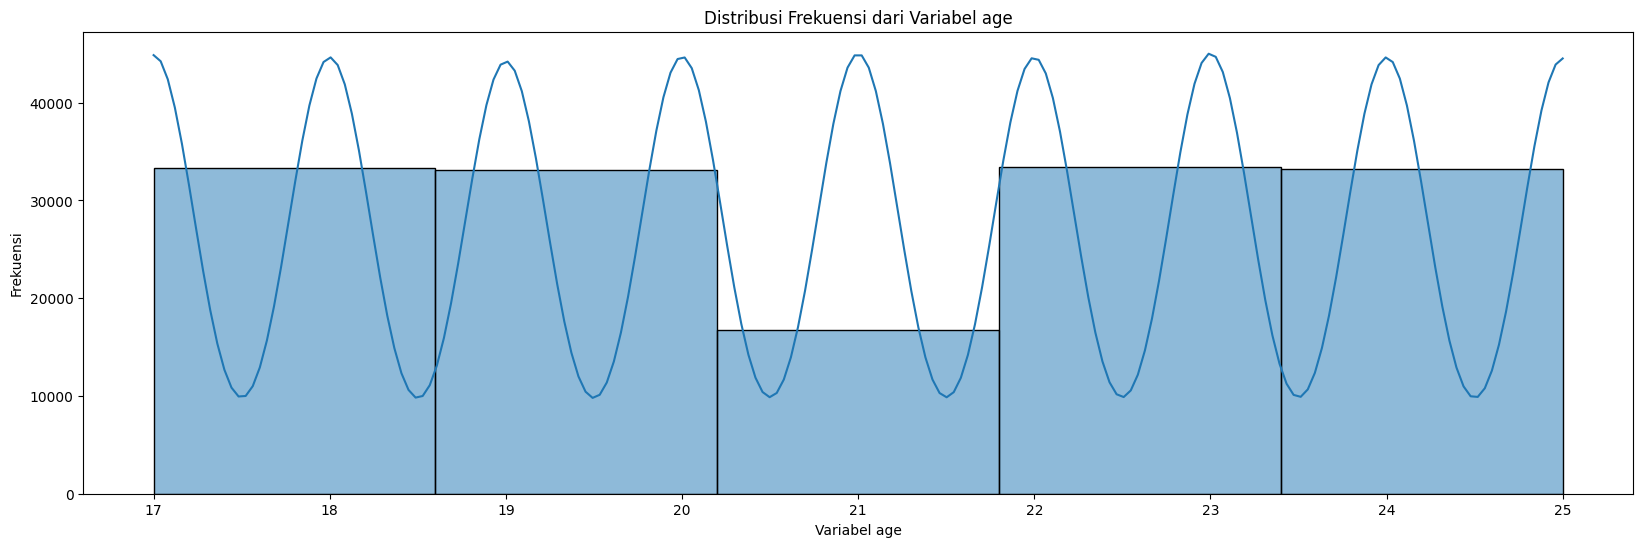

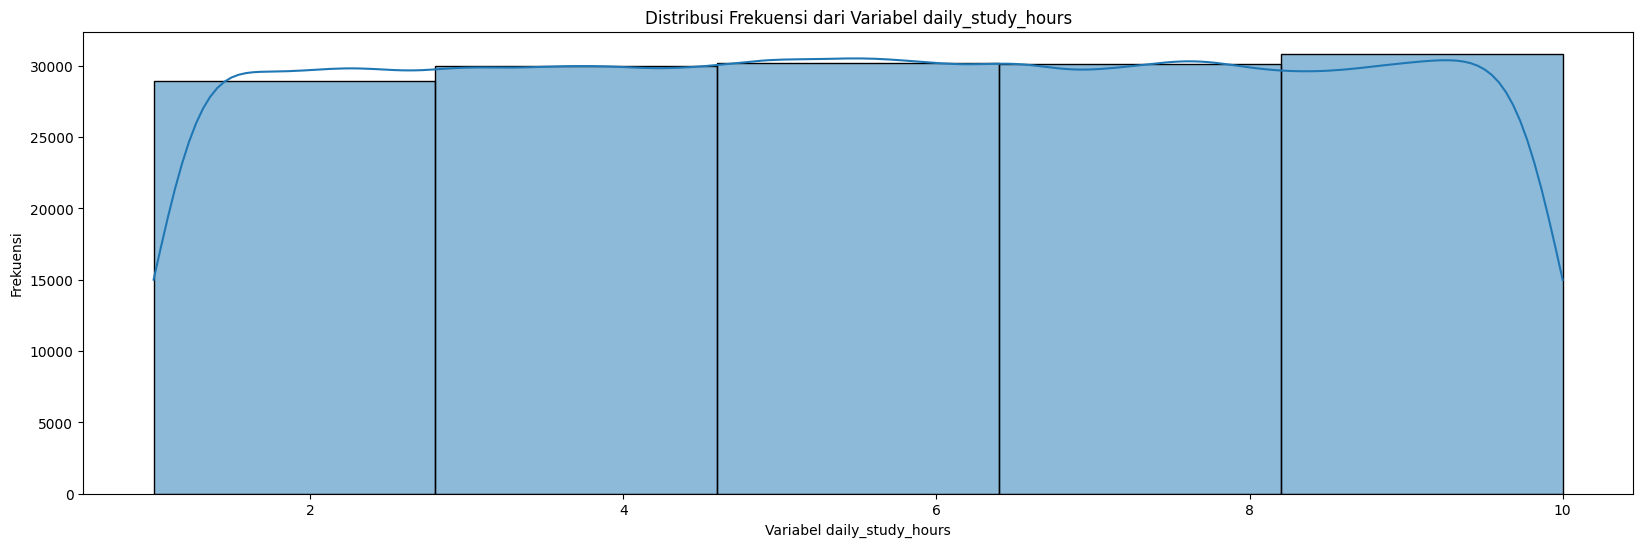

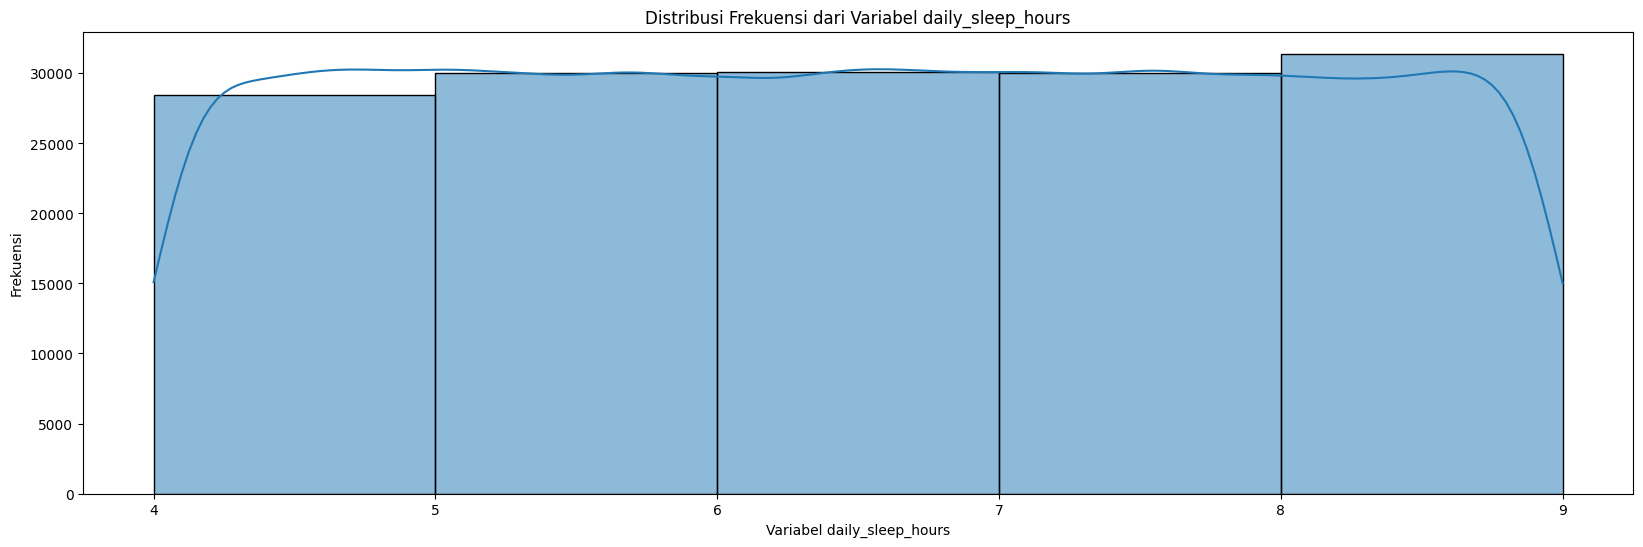

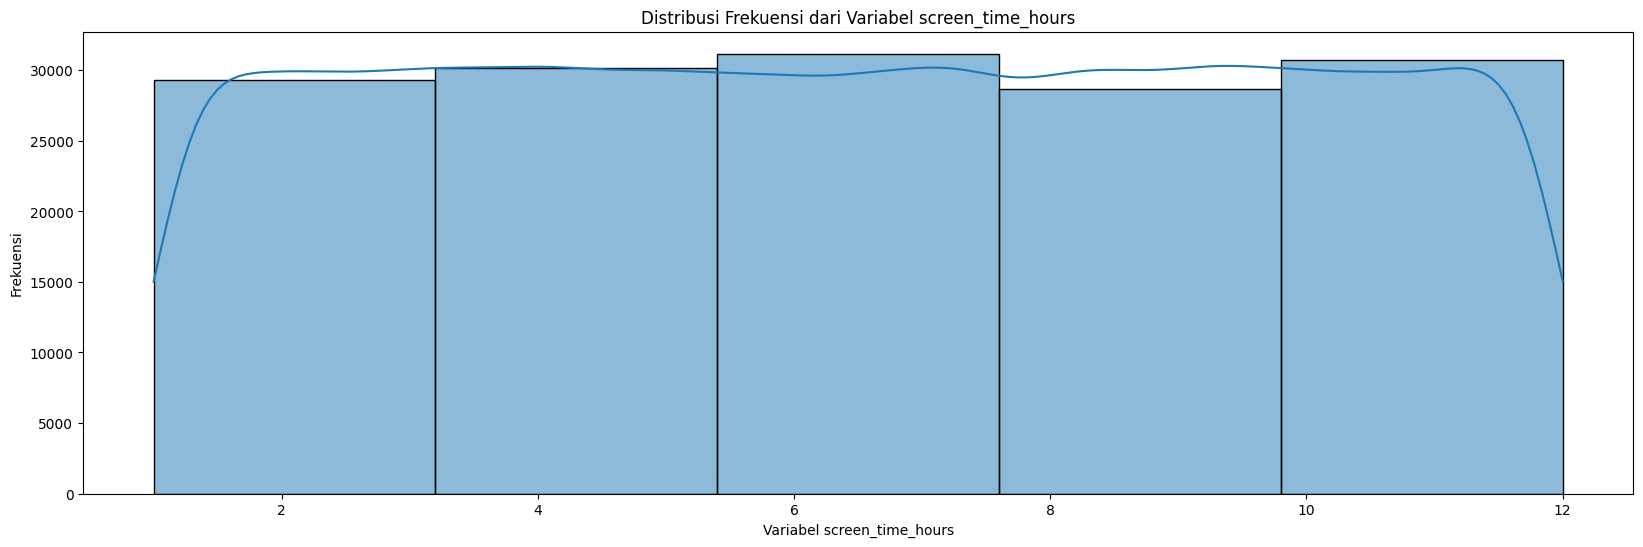

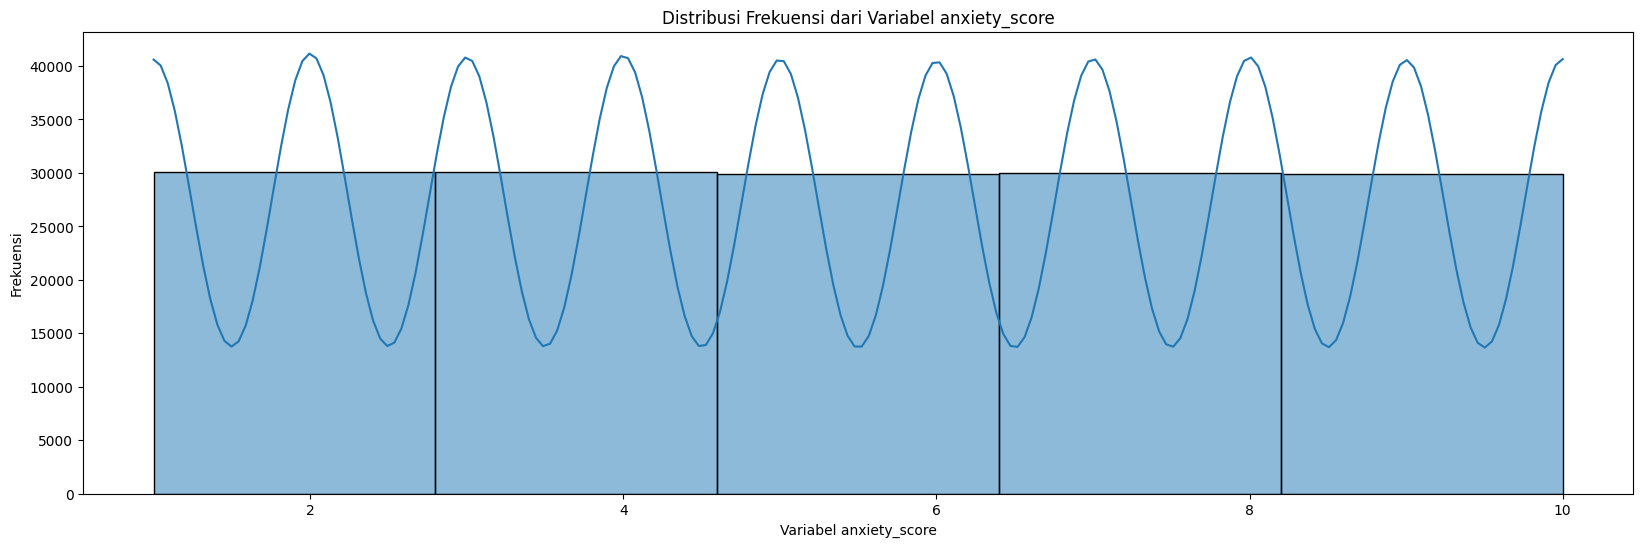

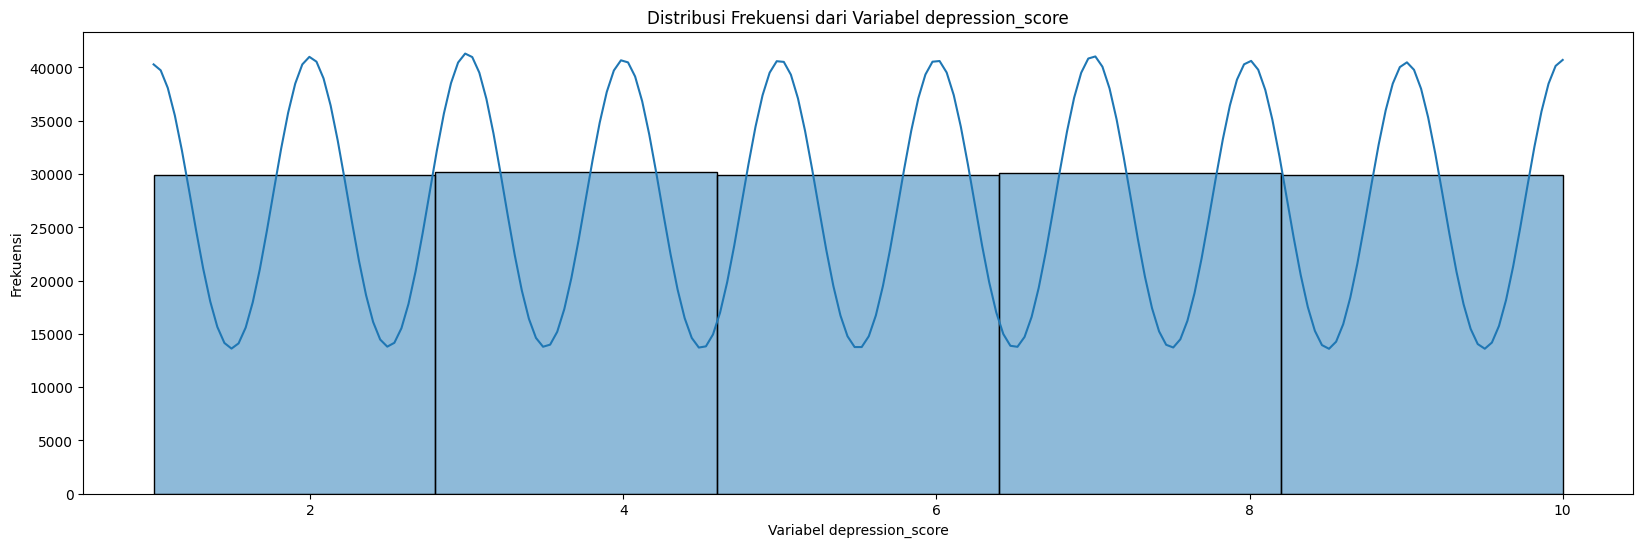

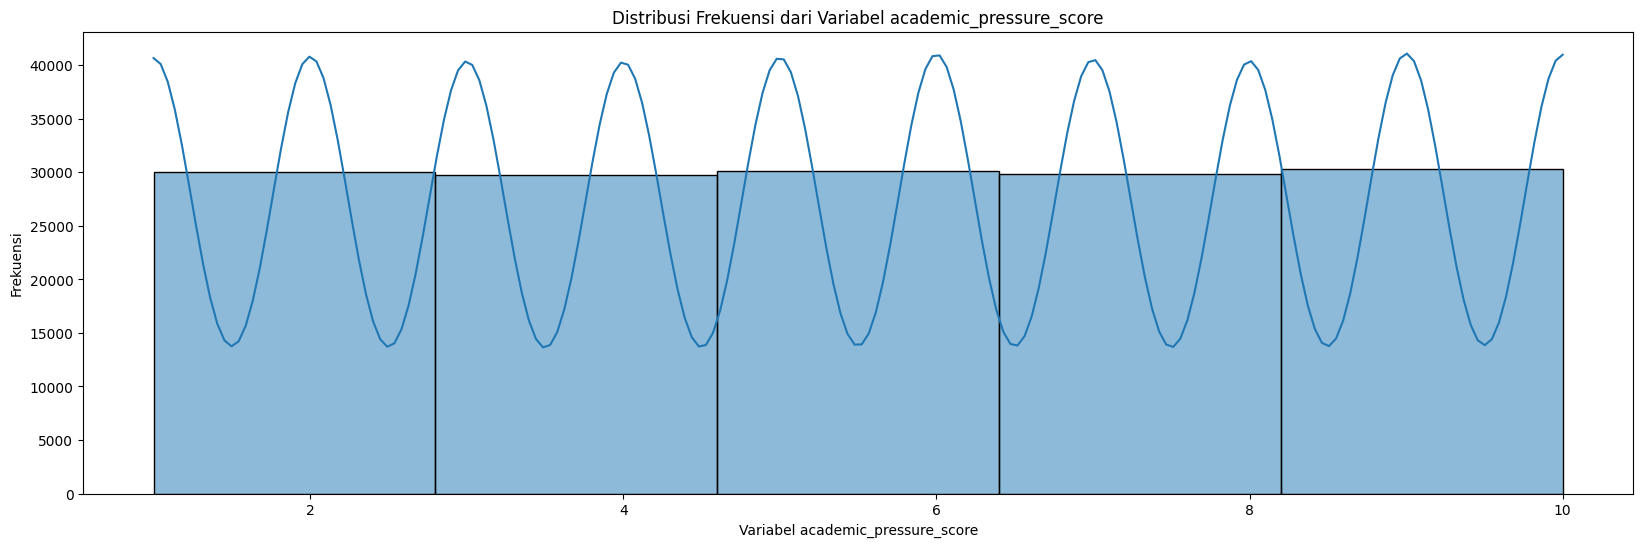

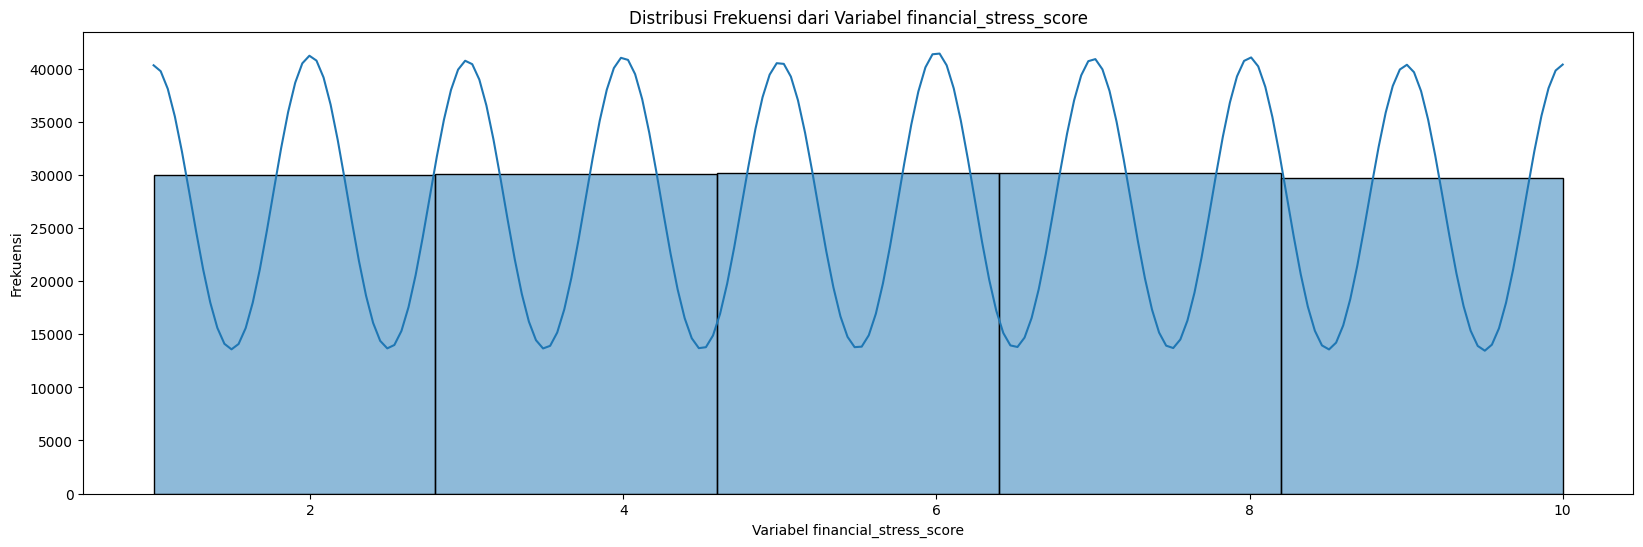

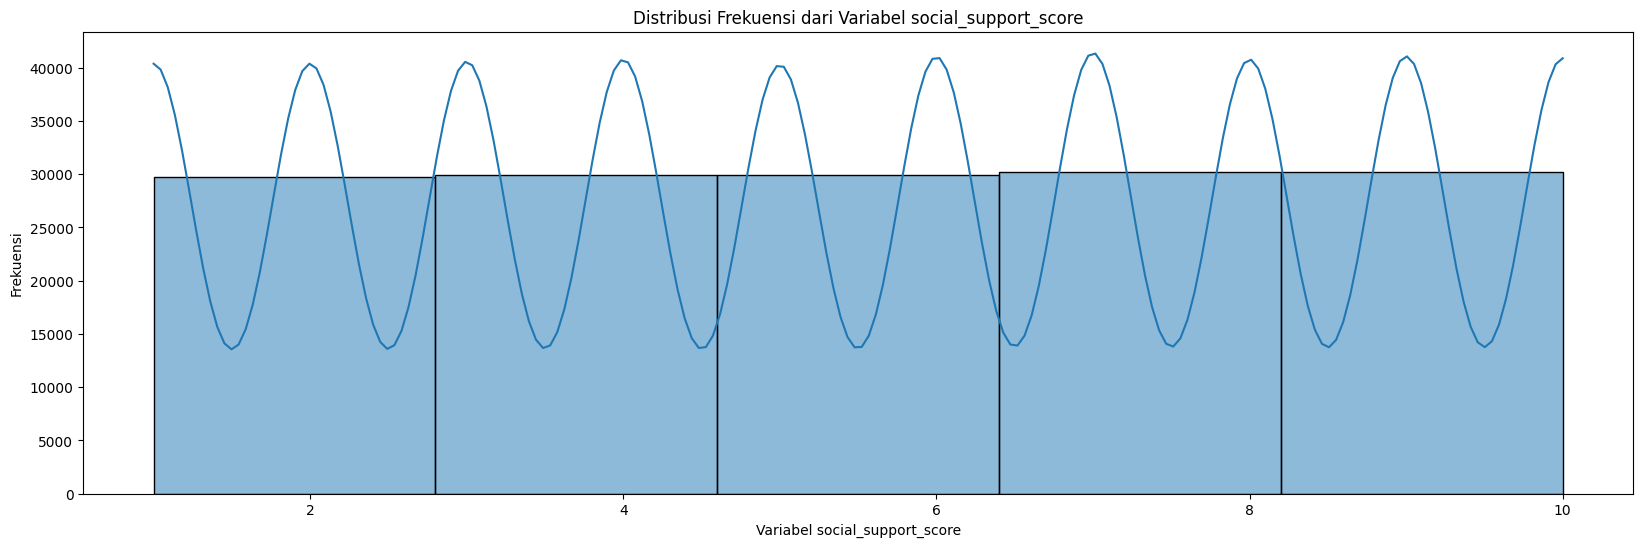

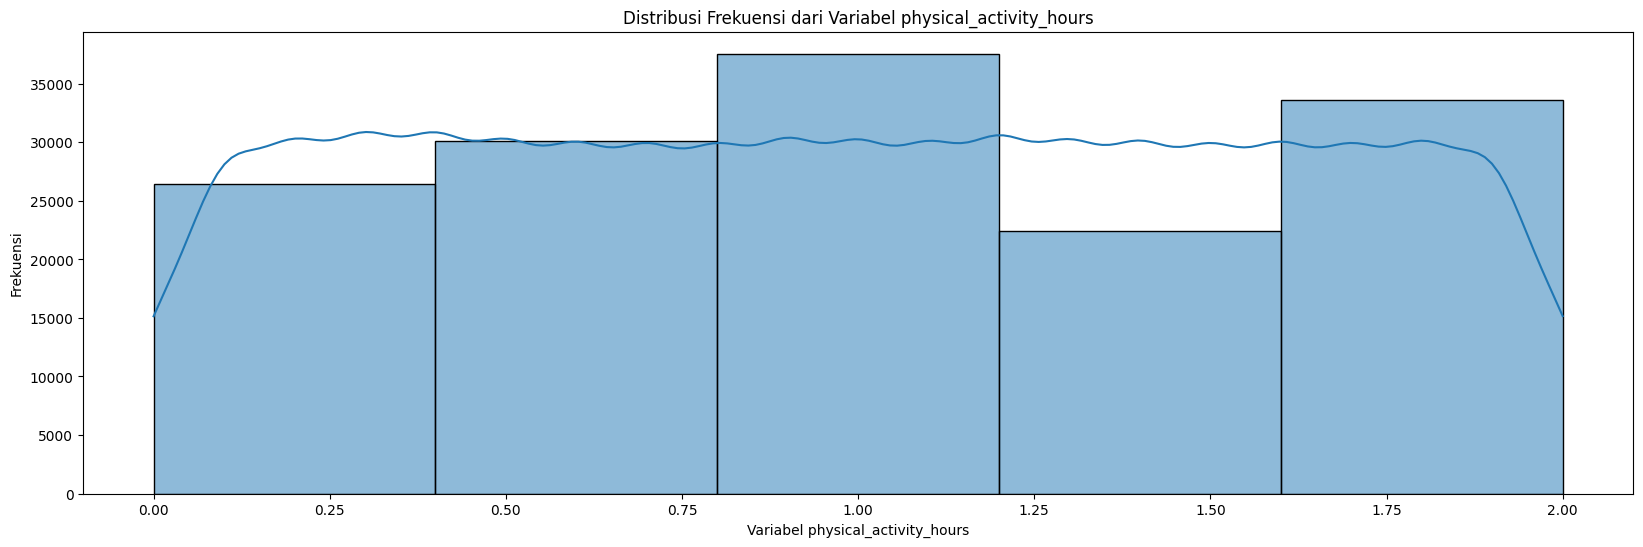

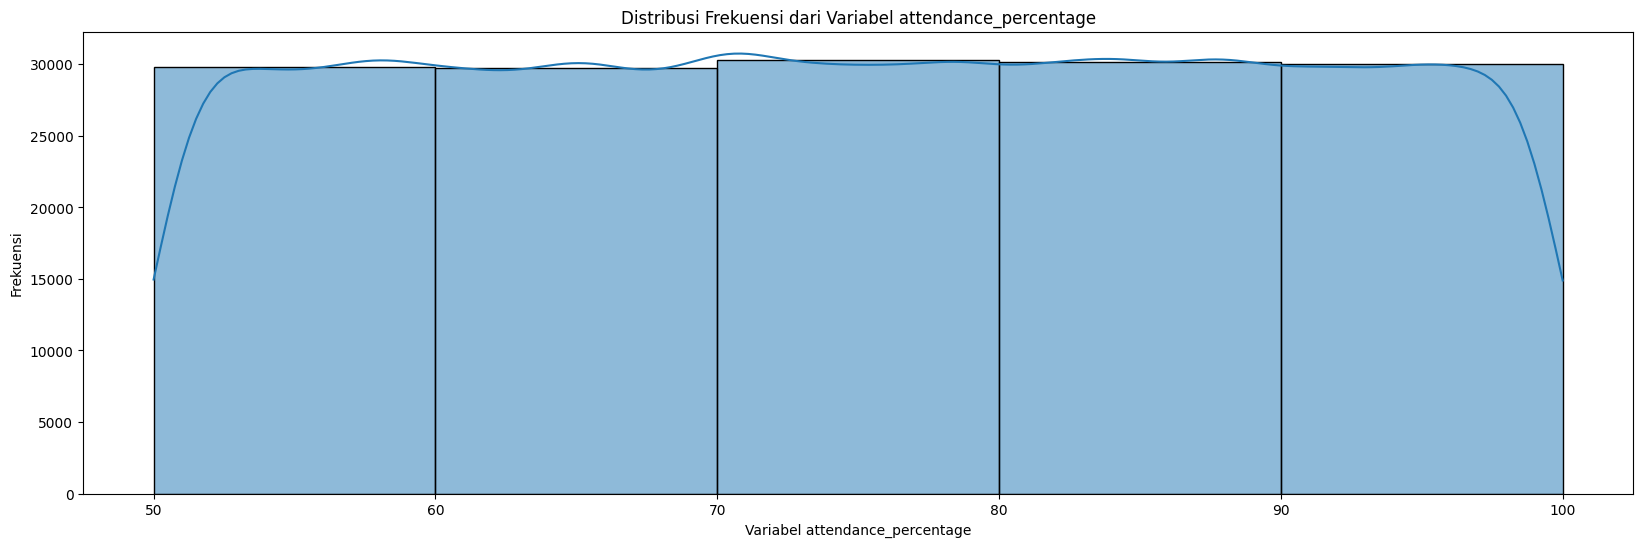

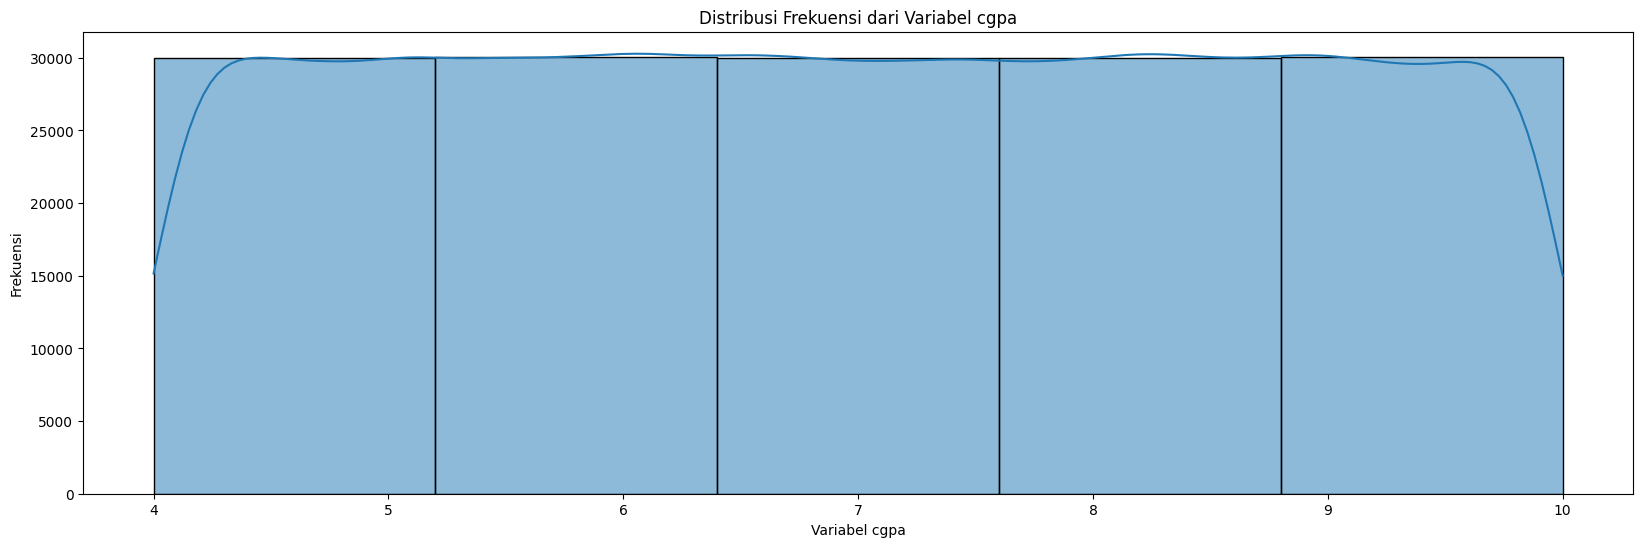

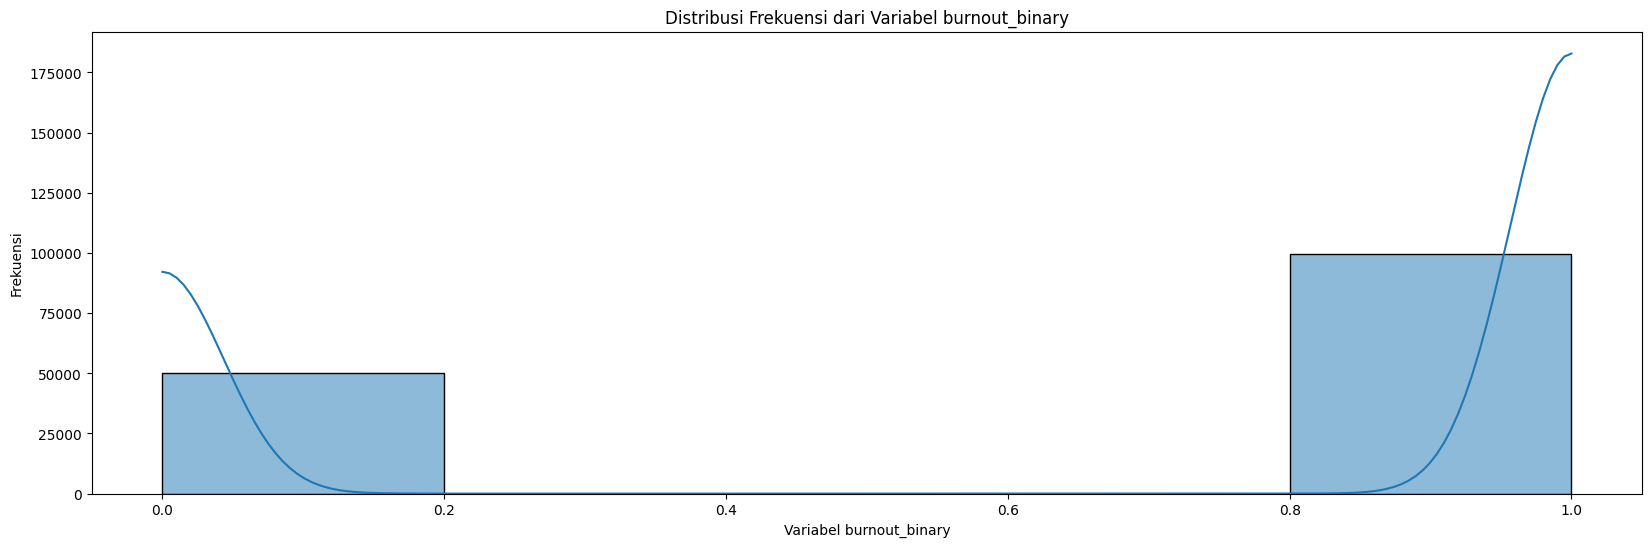

In [20]:
for i in data_numerik:
    plt.figure(figsize=(20,6))
    plt.title(f'Distribusi Frekuensi dari Variabel {i}')
    sns.histplot(data=data_numerik, x=i, bins=5, kde=True)
    plt.xlabel(f'Variabel {i}')
    plt.ylabel('Frekuensi')
    plt.show() #melihat distribusi frekuensi dari data kontinu kita

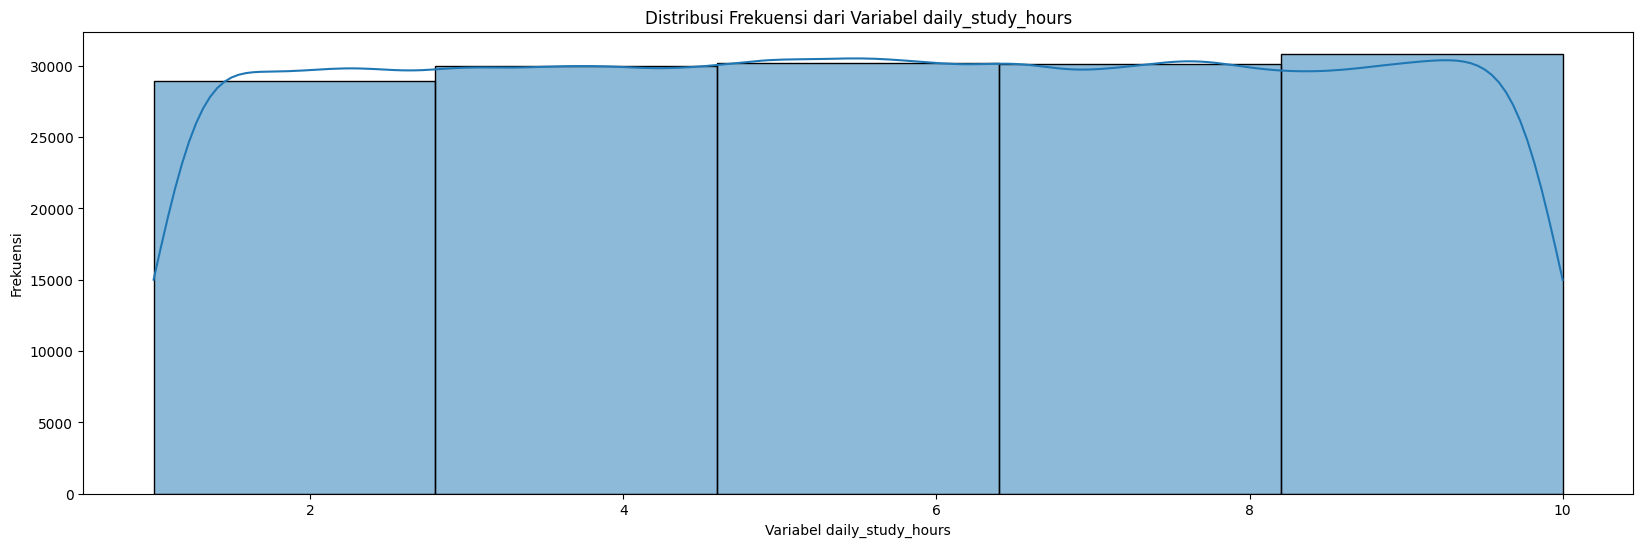

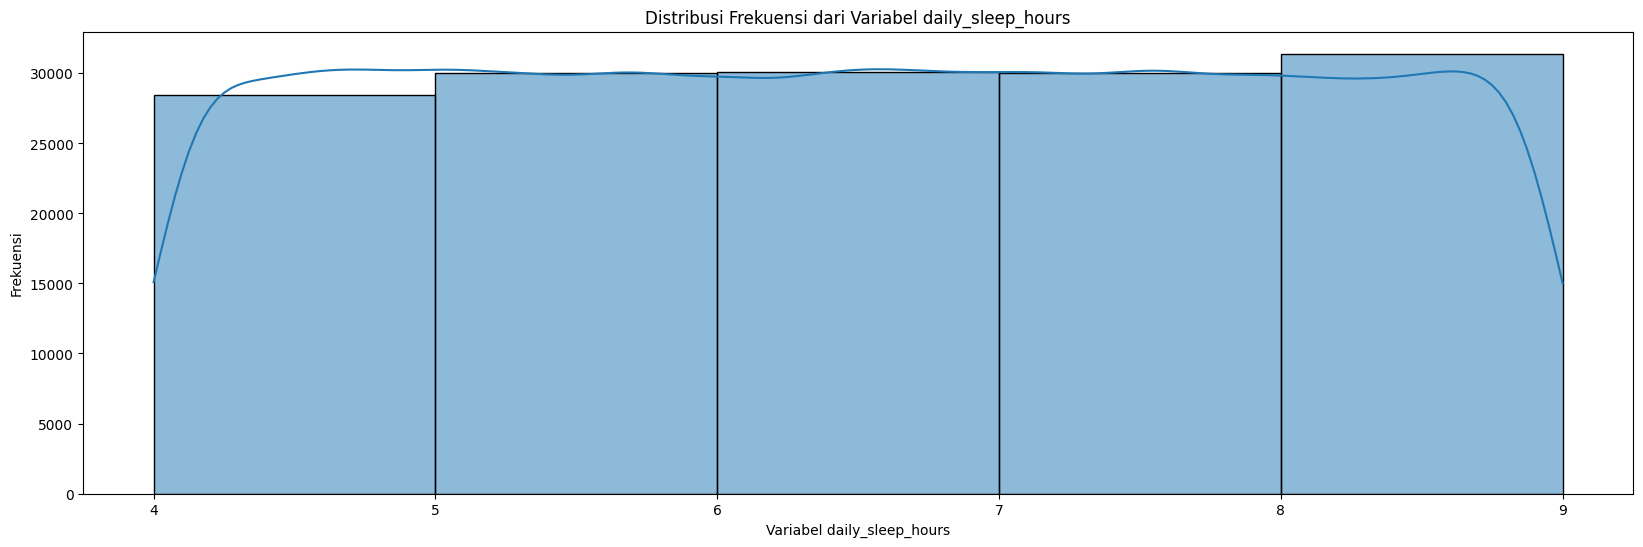

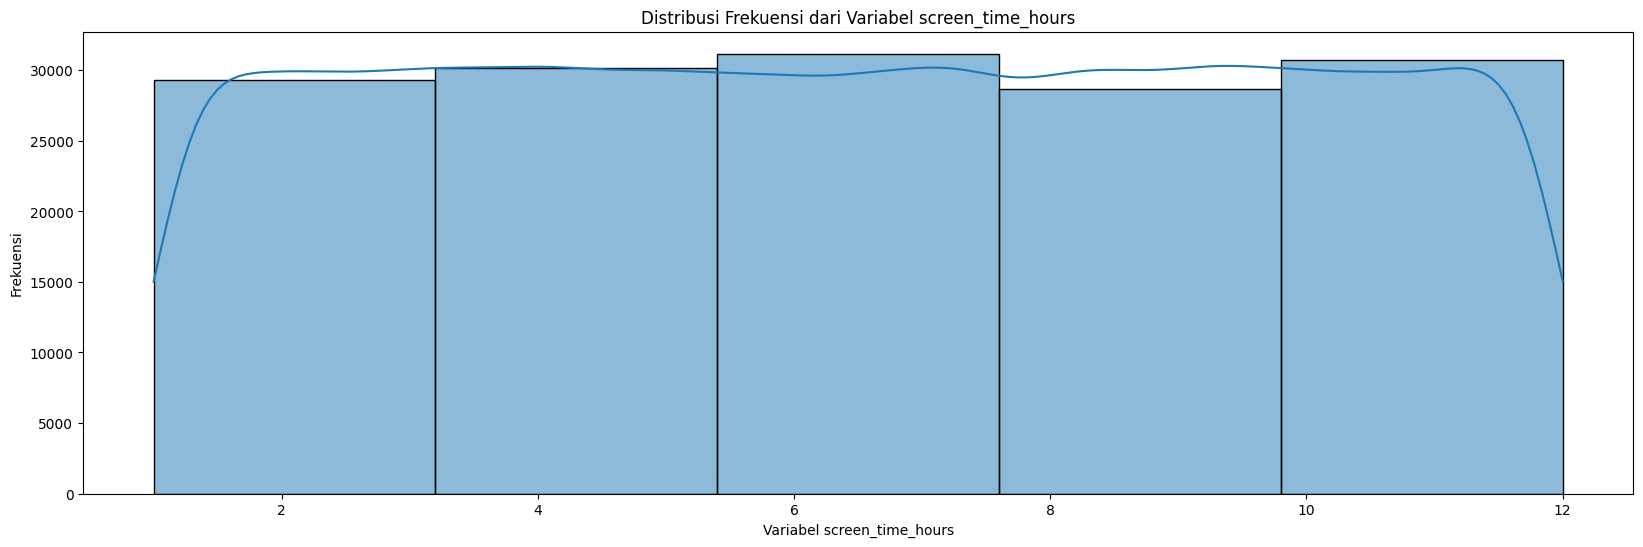

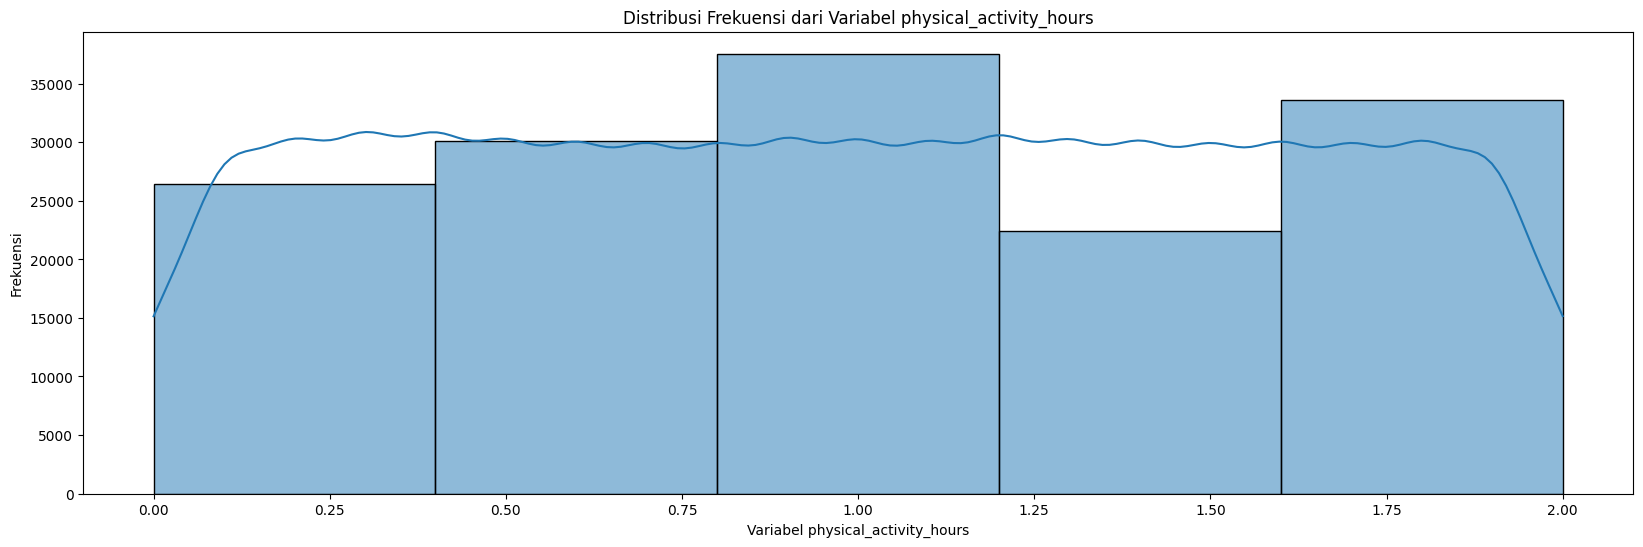

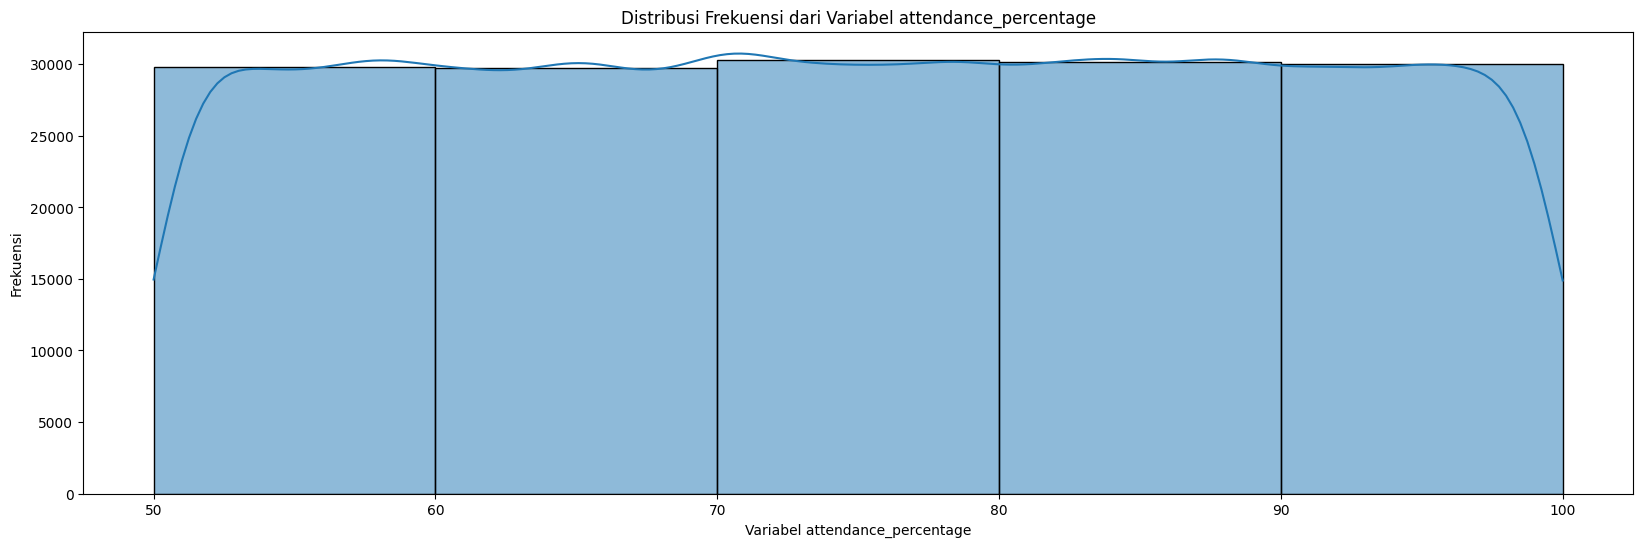

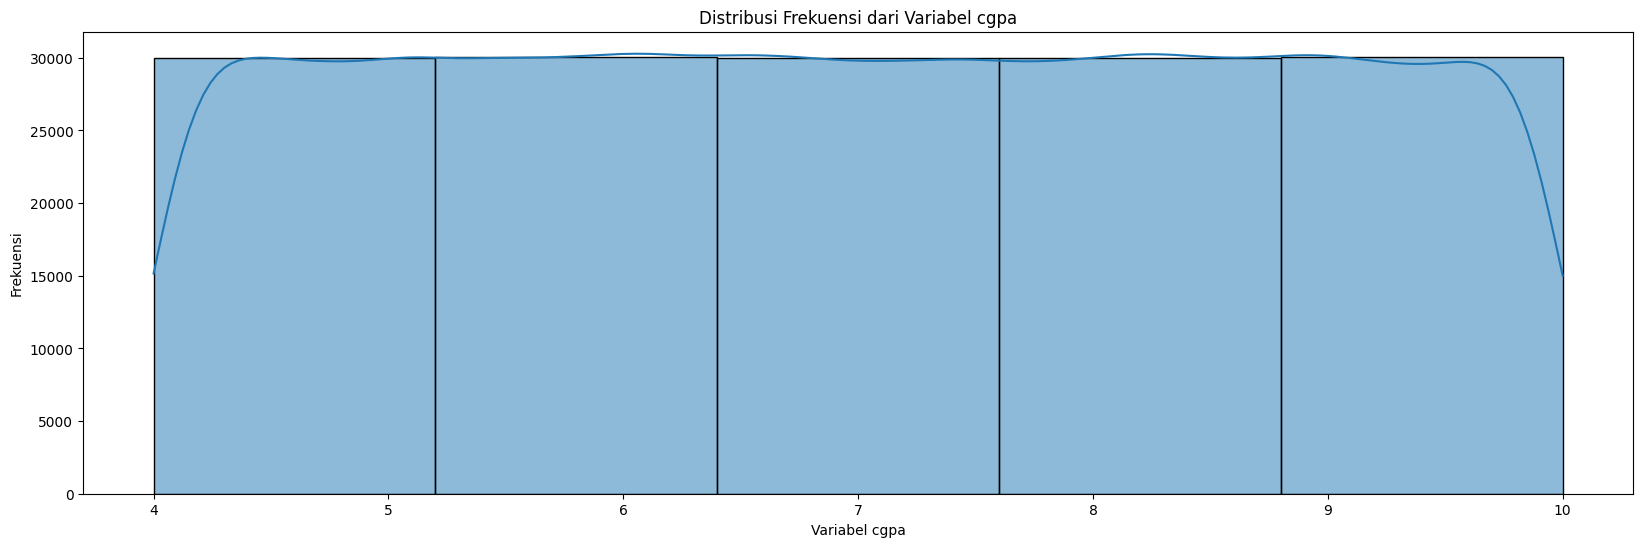

In [21]:
for i in data_kontinu:
    plt.figure(figsize=(20,6))
    plt.title(f'Distribusi Frekuensi dari Variabel {i}')
    sns.histplot(data=data_numerik, x=i, bins=5, kde=True)
    plt.xlabel(f'Variabel {i}')
    plt.ylabel('Frekuensi')
    plt.show() #melihat distribusi frekuensi dari data kontinu kita

In [22]:
for i in data_kontinu:
    print(data_numerik[i].skew()) #melihat statistika dari data kontinu kita

-0.0032618217769103688
0.0012607755423949694
2.1174532816099314e-05
0.005164841234748878
-0.002415335632504331
0.0013310578315797498


In [31]:
#aspliting data set

x = data_finalmodel.drop(columns=['burnout_binary']) #memisahkan data fitur dengan data target
y = data_finalmodel['burnout_binary']

x_latih, x_uji, y_latih, y_uji = train_test_split(x, y, test_size= 0.3, random_state=42) #memisahkan data latih dan data uji dengan rasio 70:30

print(x.shape) #melihat jumlah data fitur
print(y.shape) #melihat jumlah data target

(150000, 18)
(150000,)


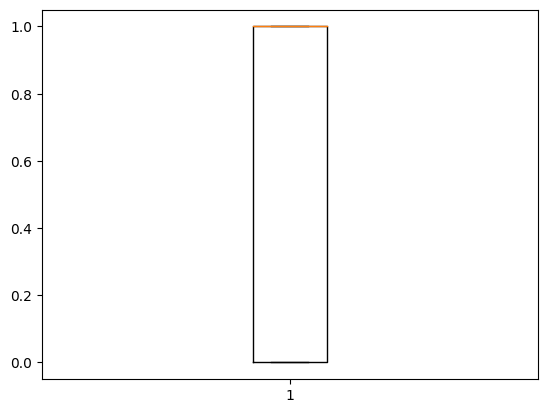

In [32]:
#outliers detectore mengunkan IQR method
Q1 = data_model['burnout_binary'].quantile(0.25)
Q3 = data_model['burnout_binary'].quantile(0.75)

IQR = Q3 - Q1

lower_data = Q1 - 1.5 * IQR
upper_data = Q3 + 1.5 * IQR

oulierts_detector = data_model[
    (data_model['burnout_binary'] < lower_data) | (data_model['burnout_binary'] > upper_data)
]

oulierts_detector
plt.boxplot(data_model['burnout_binary'])
plt.show()


In [33]:
data_object.describe()

,gender,course,year,stress_level,sleep_quality,internet_quality
count,150000,150000,150000,150000,150000,150000
unique,3,6,4,3,3,3
top,Other,MBA,1st,High,Good,Average
freq,50048,25231,37680,50295,50143,50138


In [37]:
#melihat data IR ( imabalence rasio) mengunakn if statement


for i in data_object.columns:
    
    jumlan = data_object[i].value_counts() #bagian ini untuk menghitung dsitribusi data disetiap class

    
    max_value = jumlan.max()
    min_value = jumlan.min()
    
    rasio = max_value / min_value
    
    if rasio < 1.5:
        print(f"data tidak imbalence pada kolom {i} dengan rasio{rasio:.2f}")
    elif rasio > 1.5 and rasio <= 3:
        print(f"data sedikit imbalence pada kolom {i} dengan rasio{rasio:.2f}")
    else:
        print(f"data imbalence pada kolom {i} dengan rasio{rasio:.2f}")

data tidak imbalence pada kolom gender dengan rasio1.00
data tidak imbalence pada kolom course dengan rasio1.02
data tidak imbalence pada kolom year dengan rasio1.01
data tidak imbalence pada kolom stress_level dengan rasio1.01
data tidak imbalence pada kolom sleep_quality dengan rasio1.01
data tidak imbalence pada kolom internet_quality dengan rasio1.01


In [38]:

imbalance_rasio = y_latih.value_counts()
rasio = imbalance_rasio.max() / imbalance_rasio.min()

if rasio < 1.5:
    print(f'data aman tidak imbalence {rasio}')
elif rasio > 1.5 and rasio <= 3:
    print(f"sedikit imbalence {rasio}")
else:
    print(f"data imbalence {rasio}")


sedikit imbalence 1.9888983774551665


In [48]:
x_latih_numeik = x_latih.select_dtypes(include=['float64', 'int64'])
print(x_latih_numeik)

        age  daily_study_hours  daily_sleep_hours  screen_time_hours  \
27822    21                8.3                7.8                9.8   
85202    18                9.8                7.4                2.0   
42217    24                1.5                6.0                9.3   
119958   21                1.3                8.0               11.0   
37678    20                4.0                7.9                1.8   
...     ...                ...                ...                ...   
119879   24                4.3                4.7                2.3   
103694   21                6.4                5.2                1.9   
131932   18                2.6                6.6                3.5   
146867   17                6.6                5.9               11.6   
121958   21                8.4                4.7                7.9   

        anxiety_score  depression_score  academic_pressure_score  \
27822               6                 9                        8   

In [50]:
#misahkan data disrtik dan data kontinu

nilai_uniq = 15
kontinu = []
distrik = [] 

for i in x_latih_numeik.columns:
    data_unik = x_latih_numeik[i].nunique()
    if data_unik < nilai_uniq:
        distrik.append(i)
    else:
        kontinu.append(i)
print(f'======= data distrik =======')
print(distrik)
print(f'======= data kontinu =======')
print(kontinu)  

======= data distrik =======
['age', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score']
======= data kontinu =======
['daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'physical_activity_hours', 'attendance_percentage', 'cgpa']


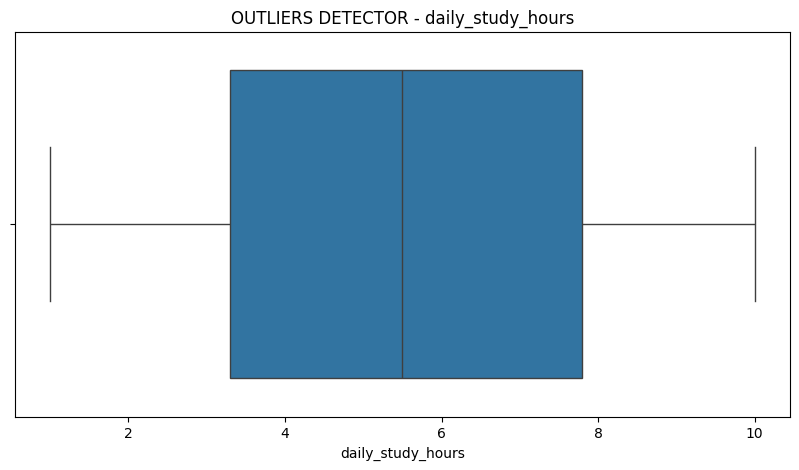

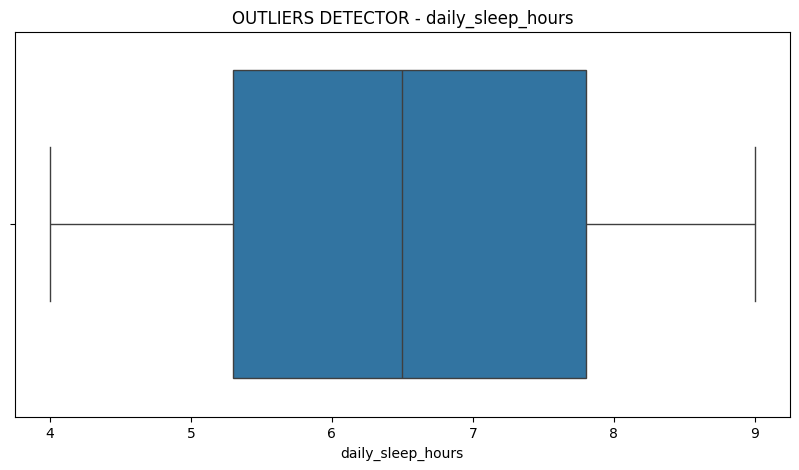

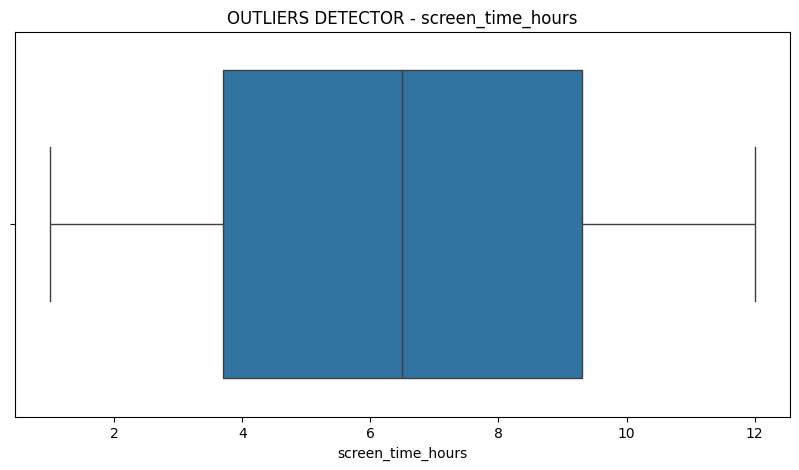

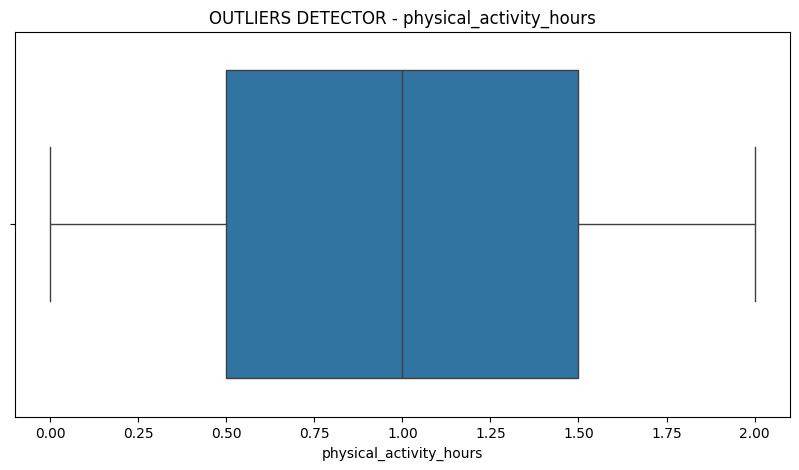

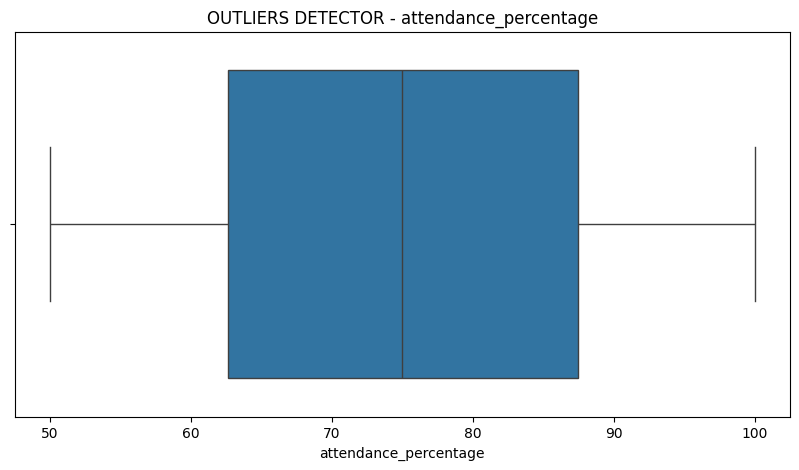

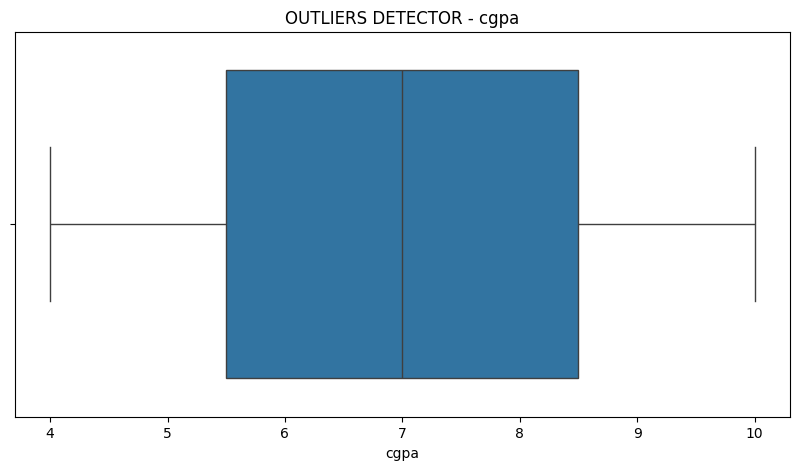

In [51]:


#outlier detection mengunkan boxplot
#kirta gunakan x_latih karna kita sudah spliting dahulu data nya
for column in kontinu: #disini kita menggabil data numerik saja karna outliers biasa nya hanya untuk data numerik
    plt.figure(figsize=(10, 5))
    sns.boxplot(x =x_latih[column])
    plt.title(f'OUTLIERS DETECTOR - {column}')
    plt.show()

In [41]:
data_numerik

,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa
27822,21,8.3,7.8,9.8,6,9,8,6,10,1.9,58.2,6.13
85202,18,9.8,7.4,2.0,4,4,5,8,3,1.6,72.9,4.87
42217,24,1.5,6.0,9.3,7,3,6,8,7,0.6,74.2,8.30
119958,21,1.3,8.0,11.0,4,7,5,10,6,0.4,58.3,5.32
37678,20,4.0,7.9,1.8,5,8,1,2,8,0.8,67.2,6.22
...,...,...,...,...,...,...,...,...,...,...,...,...
119879,24,4.3,4.7,2.3,10,6,1,5,10,1.3,77.6,5.77
103694,21,6.4,5.2,1.9,8,4,1,7,8,1.0,54.0,8.74
131932,18,2.6,6.6,3.5,4,6,2,5,10,0.4,88.9,8.01
146867,17,6.6,5.9,11.6,6,1,5,5,9,0.2,72.8,6.23


In [ ]:
#menganalisa lorasi antar 2 variabel (bivariate analysis) menggunakan scatter plot

In [54]:
#menghitung matrix kolerasi antar variabel numerik

kolerasi = x_latih_numeik.corr()
print(kolerasi)

                              age  daily_study_hours  daily_sleep_hours  \
age                      1.000000           0.000159           0.000465   
daily_study_hours        0.000159           1.000000          -0.003981   
daily_sleep_hours        0.000465          -0.003981           1.000000   
screen_time_hours        0.002057           0.000809          -0.000724   
anxiety_score           -0.001343           0.000734           0.004669   
depression_score        -0.000740          -0.001005          -0.004048   
academic_pressure_score  0.003550          -0.004385          -0.003378   
financial_stress_score  -0.001548           0.002984           0.004768   
social_support_score    -0.001111          -0.002582          -0.005006   
physical_activity_hours -0.003273           0.003554           0.000125   
attendance_percentage   -0.001591           0.002884           0.000390   
cgpa                    -0.006738          -0.006054          -0.005822   

                        

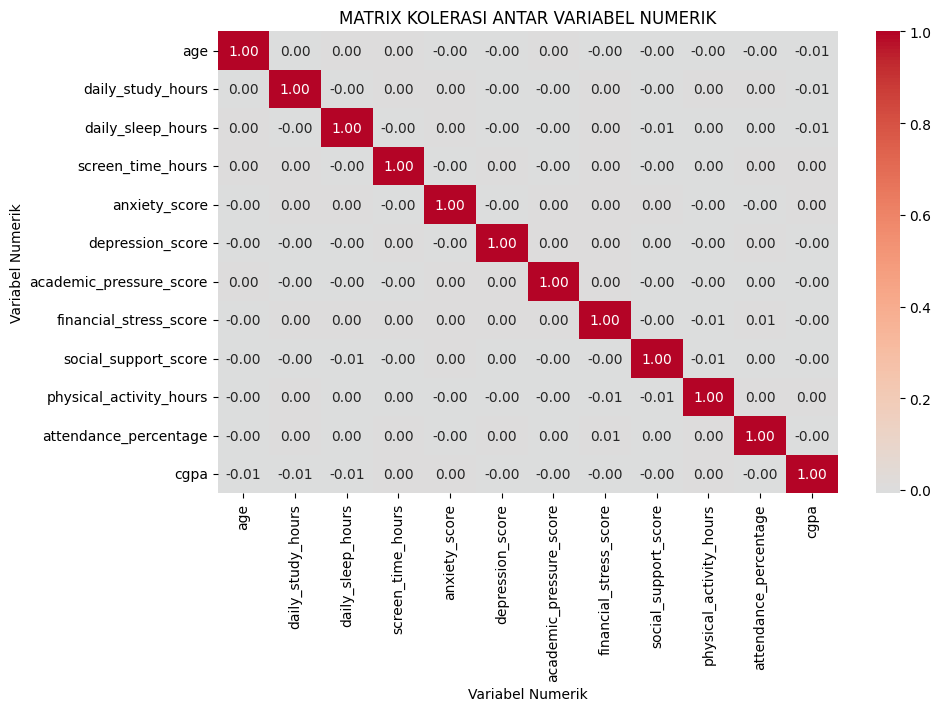

In [55]:
#visualisasi kolerasi

plt.figure(figsize=(10, 6))
sns.heatmap(kolerasi, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('MATRIX KOLERASI ANTAR VARIABEL NUMERIK')
plt.xlabel('Variabel Numerik')
plt.ylabel('Variabel Numerik')
plt.show()